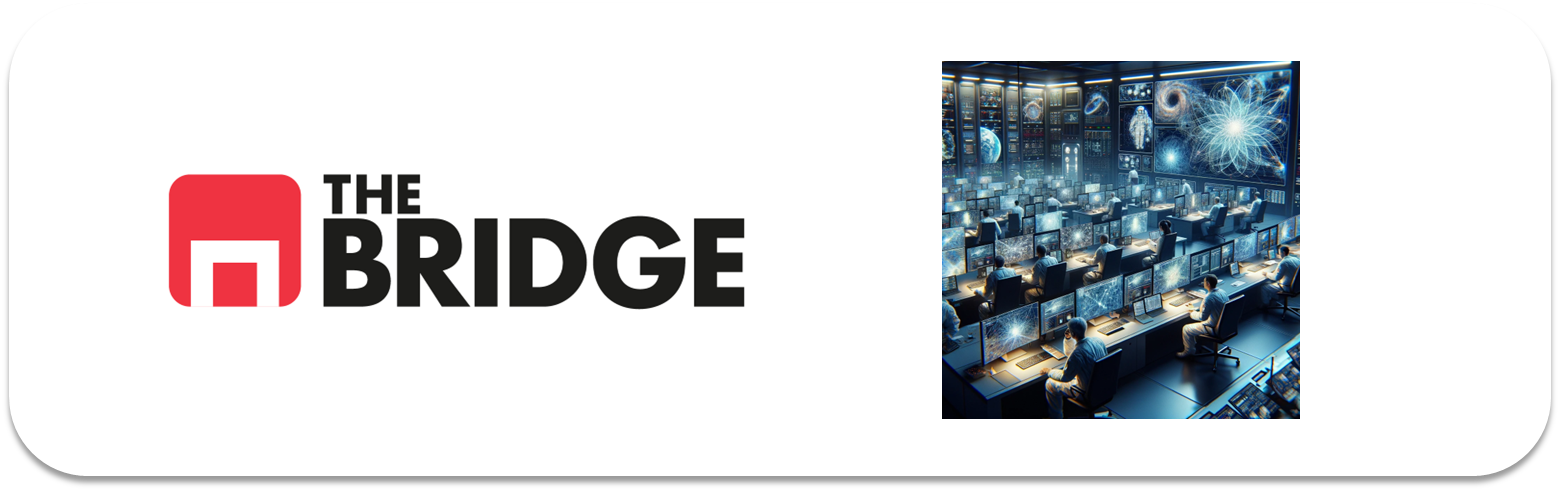

## PRACTICA OBLIGATORIA: **Redes Convolucionales**

* La práctica obligatoria de esta unidad consiste en un ejercicio de construcción de una red convolucional con Keras para la clasificación de imagenes de simpáticos perretes y gatetes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

### Problema de Negocio y dataset

Una conocida empresa de información inmobiliaria utiliza un CAPTCHA visual de perros y gatos para detectar webscrappings intensivos y ataques de denegación de servicio. Últimamente, ha detectado que su sistema está empezando a flojear, es decir que hay muchos sistemas de detección automática de imágenes que son capaces de detectar que es un perro y un gato y salterse el CAPTCHA antirobots. Por eso nos ha pedido que entrenemos un modelo potente de clasificación que emule a estos sistemas con el objetivo de emplear como fotografías para el CAPTCHA aquellas que no sepa detectar este sistema emulador de chicos malos.  

Pues manos a la obra, tenemos que seleccionar en un conjunto de 1000 imágenes aquellas que peor se le daría clasificar a un potencial sistema anti-CAPTCHA.  

Para ello vamos a emplear un conjunto de train de 4000 imágenes de perretes y gatetes que se encuentran distribuidas en "data" en cuatro directorios "github_train_0",  "github_train_1", "githun_train_2" y "github_train_3". Los datos de las imagenes que tenemos que clasificar y luego seleccionar como las más "difíciles" están en "data" en el directorio "github_test".


### Se pide

1. Crear los datasets X,y de train y test, leyendo las imágenes de los directorios correspondientes (tendrás que leer todas las imágenes de los cuatro directorios para train) y a la vez que se leen adpatar su resolución para que todas tengan un tamaño de 32x32. En este caso puedes adaptar las funciones de los ejercicios de la unidad. NOTA: Ten en cuenta que la clase a la que pertenece en la foto está en el nombre del archivo.

2. Crea un modelo DL basado en redes convolucionales con al menos dos juegos Convolucional-Pooling. Sigue todo el proceso de ML (visualización del dataset, MiniEDA, Construcción del modelo)

3. Entrenar el modelo con un callback de Earlystopping con paciencia la que tengas :-). Muestra su historial de entrenamiento.

4. Evalua el modelo, haz un reporte de clasificacion y muestra la matriz de confianza.

5. Es el momento de seleccionar las imagenes: Selecciona el 10% de imágenes mal clasificadas de una y otra clase que tengan el mayor nivel de confianza de que pertenencían a la clase errónea. Es decir las imágenes de perros clasificadas como gatos y con la probabilidad de ser perror más alta.


### Extra (para hacer en clase)

Repite los pasos 3 a 5 utilizando el generador de imágenes sintéticas o Image Augmentation de Keras. 



In [1]:
import os
import cv2
import numpy as np
import pandas as pd

In [2]:
# Función para obtener la etiqueta desde el nombre del archivo

def get_label_from_filename(filename):
    fname = filename.lower()
    if "dog" in fname:
        return 1   # perro
    elif "cat" in fname:
        return 0   # gato
    else:
        raise ValueError(f"No se detecta clase en el nombre del archivo: {filename}")


In [3]:
# Función para leer imágenes, redimensionarlas y normalizarlas

IMG_SIZE = 32

def load_images_from_dirs(base_path, dir_list):
    X = []
    y = []

    for d in dir_list:
        full_dir = os.path.join(base_path, d)

        for fname in os.listdir(full_dir):
            fpath = os.path.join(full_dir, fname)

            # Leer imagen
            img = cv2.imread(fpath)
            if img is None:
                continue

            # Convertir BGR → RGB
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Redimensionar a 32x32
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            # Normalización a [0,1]
            img = img.astype("float32") / 255.0

            # Etiqueta desde el nombre del archivo
            label = get_label_from_filename(fname)

            X.append(img)
            y.append(label)

    return np.array(X), np.array(y)


In [4]:
# Directorios

base_path = "data"

train_dirs = ["github_train_0", "github_train_1", "github_train_2", "github_train_3"]

test_dirs  = ["github_test"]


In [5]:
# Creamos los datasets

X_train, y_train = load_images_from_dirs(base_path, train_dirs)
X_test, y_test   = load_images_from_dirs(base_path, test_dirs)


In [6]:
print("Train:", X_train.shape, y_train.shape)
print("Test:",  X_test.shape,  y_test.shape)

print("Clases en train:", np.unique(y_train, return_counts=True))
print("Clases en test:",  np.unique(y_test, return_counts=True))


Train: (4000, 32, 32, 3) (4000,)
Test: (1000, 32, 32, 3) (1000,)
Clases en train: (array([0, 1]), array([2000, 2000]))
Clases en test: (array([0, 1]), array([500, 500]))


In [7]:
# MiniEDA

In [8]:
# Verificar valores de los píxeles (normalización correcta)

print("Min pixel:", X_train.min())
print("Max pixel:", X_train.max())


Min pixel: 0.0
Max pixel: 1.0


In [9]:
# Dimensiones y estructura del dataset

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


X_train: (4000, 32, 32, 3)
y_train: (4000,)
X_test: (1000, 32, 32, 3)
y_test: (1000,)


In [10]:
# Distribución de las clases

unique, counts = np.unique(y_train, return_counts=True)
print("Distribución en train:", dict(zip(unique, counts)))

unique, counts = np.unique(y_test, return_counts=True)
print("Distribución en test:", dict(zip(unique, counts)))

Distribución en train: {np.int64(0): np.int64(2000), np.int64(1): np.int64(2000)}
Distribución en test: {np.int64(0): np.int64(500), np.int64(1): np.int64(500)}


In [11]:
# Visualización de algunas imágenes

import matplotlib.pyplot as plt

def plot_images(images, labels=None, n_cols=5):
    n_rows = (len(images) - 1) // n_cols + 1
    plt.figure(figsize=(n_cols * 2, n_rows * 2.2))

    for i, img in enumerate(images):
        plt.subplot(n_rows, n_cols, i + 1)
        plt.imshow(img)
        plt.axis("off")
        if labels is not None:
            plt.title("Perro" if labels[i] == 1 else "Gato")

    plt.tight_layout()
    plt.show()


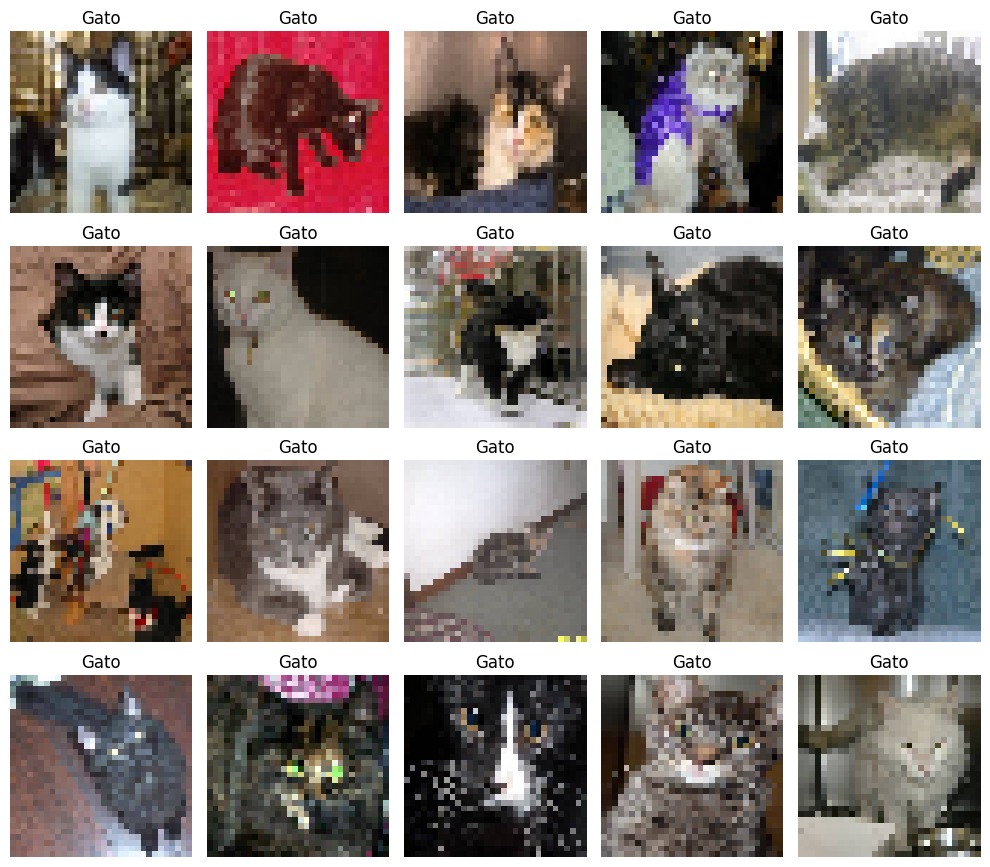

In [12]:
plot_images(X_train[:20], y_train[:20])

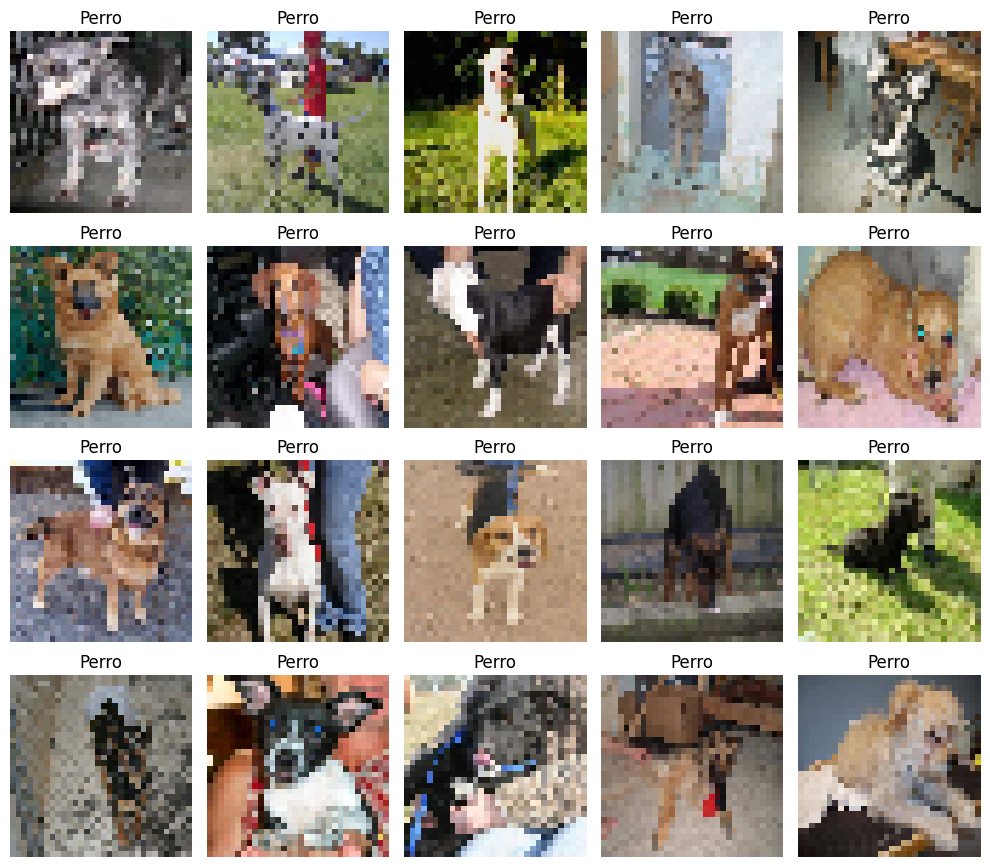

In [13]:
plot_images(X_train[2000:2020], y_train[2000:2020])


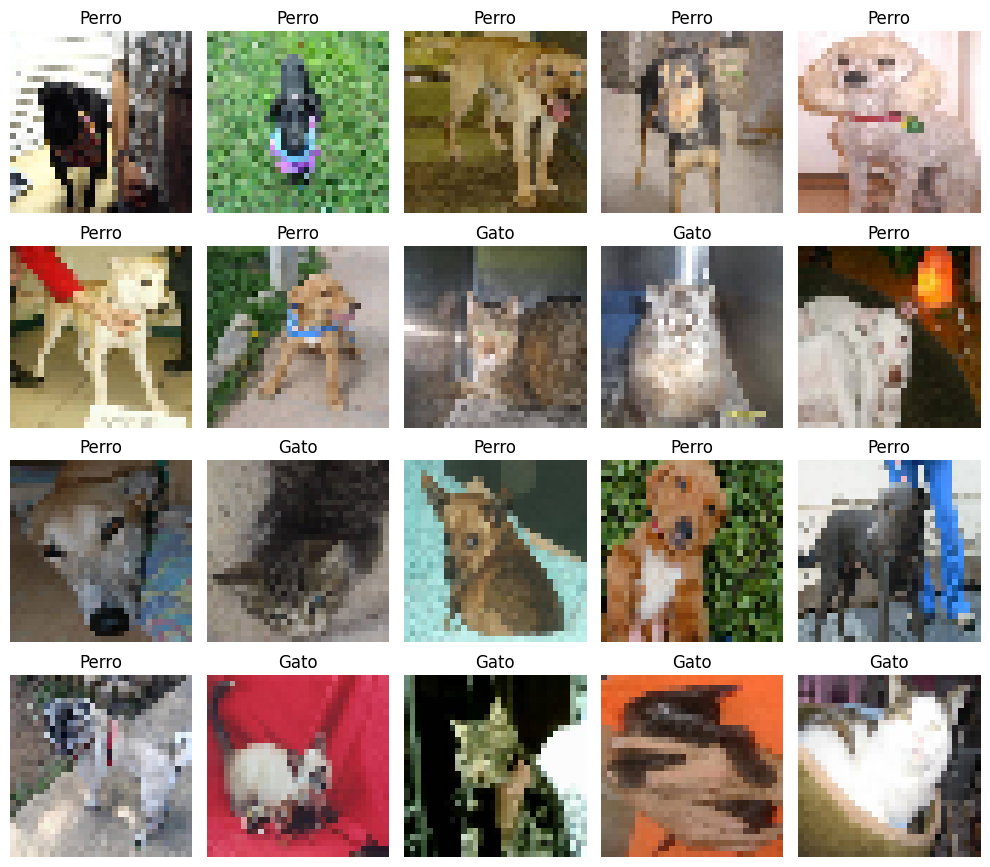

In [14]:
# Comprobación de variabilidad

idxs = np.random.randint(0, len(X_train), 20)
plot_images(X_train[idxs], y_train[idxs])


In [15]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    keras.layers.Input(shape=(32,32,3)),   

    keras.layers.Conv2D(32, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 314,561 (1.20 MB)

 Trainable params: 314,561 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Entrenamiento del modelo con earlystop

from tensorflow.keras.callbacks import EarlyStopping

es = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,   # 20% del train se usa como validación
    epochs=50,
    batch_size=32,
    callbacks=[es],
    verbose=1
)


Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6212 - loss: 0.6620 - val_accuracy: 0.0000e+00 - val_loss: 1.0805
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6784 - loss: 0.6186 - val_accuracy: 0.2800 - val_loss: 0.9168
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6988 - loss: 0.5866 - val_accuracy: 0.5625 - val_loss: 0.7181
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7116 - loss: 0.5619 - val_accuracy: 0.3775 - val_loss: 0.9509
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7334 - loss: 0.5222 - val_accuracy: 0.4512 - val_loss: 0.9261
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7550 - loss: 0.4957 - val_accuracy: 0.4462 - val_loss: 0.9488
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7853 - loss: 0.4541 - val_accuracy: 0.6662 - val_loss: 0.6681
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7969 - loss: 0.4263 - val_ac

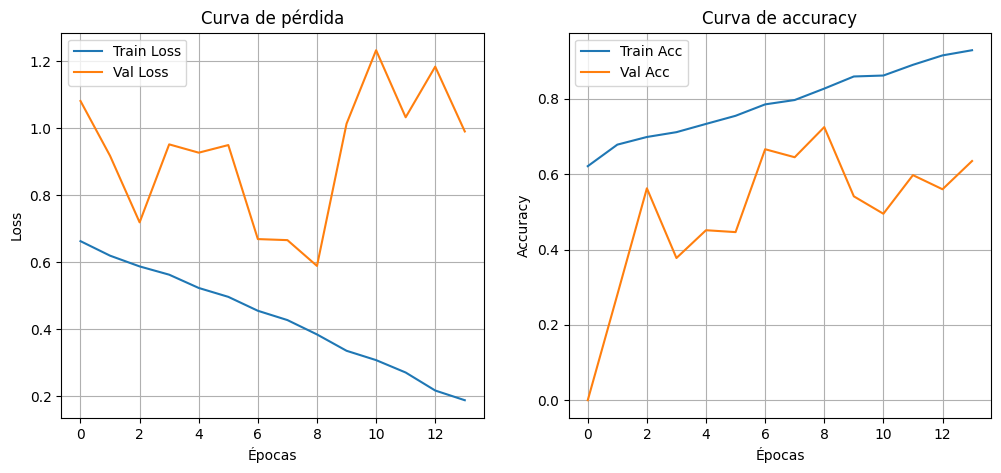

In [17]:
import matplotlib.pyplot as plt

# --- Pérdida ---
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Curva de pérdida')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# --- Accuracy ---
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Curva de accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()


In [18]:
# Evaluar el modelo en el conjunto de test

test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7420 - loss: 0.5316
Test Loss: 0.5315943956375122
Test Accuracy: 0.7419999837875366


In [19]:
# Obtener predicciones

y_pred = model.predict(X_test)


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [20]:
# Convertir predicciones a clases

y_pred_classes = (y_pred > 0.5).astype("int32")

In [21]:
# Identificar imágenes falladas por el modelo

errores = np.where(y_pred_classes.flatten() != y_test)[0]
len(errores)


258

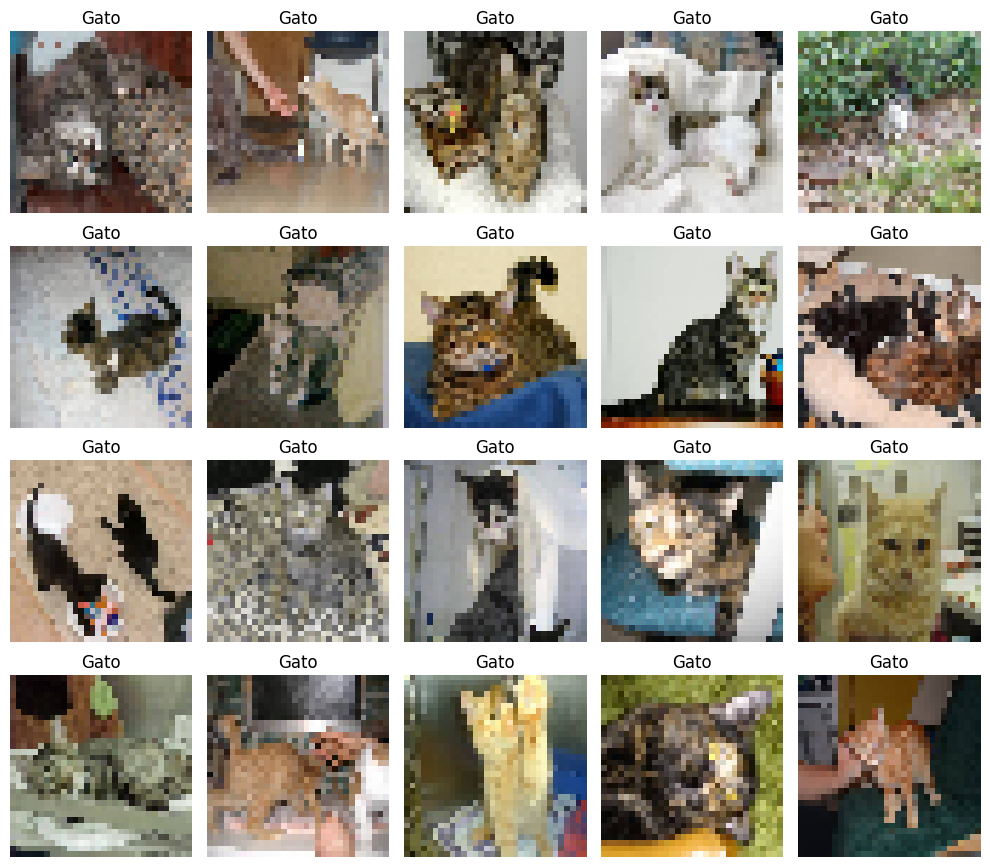

In [22]:
idxs = errores[:20]   # las primeras 20 falladas
plot_images(X_test[idxs], y_test[idxs])


In [23]:
prob = y_pred.flatten()
incertidumbre = np.where((prob > 0.4) & (prob < 0.6))[0]
len(incertidumbre)


155

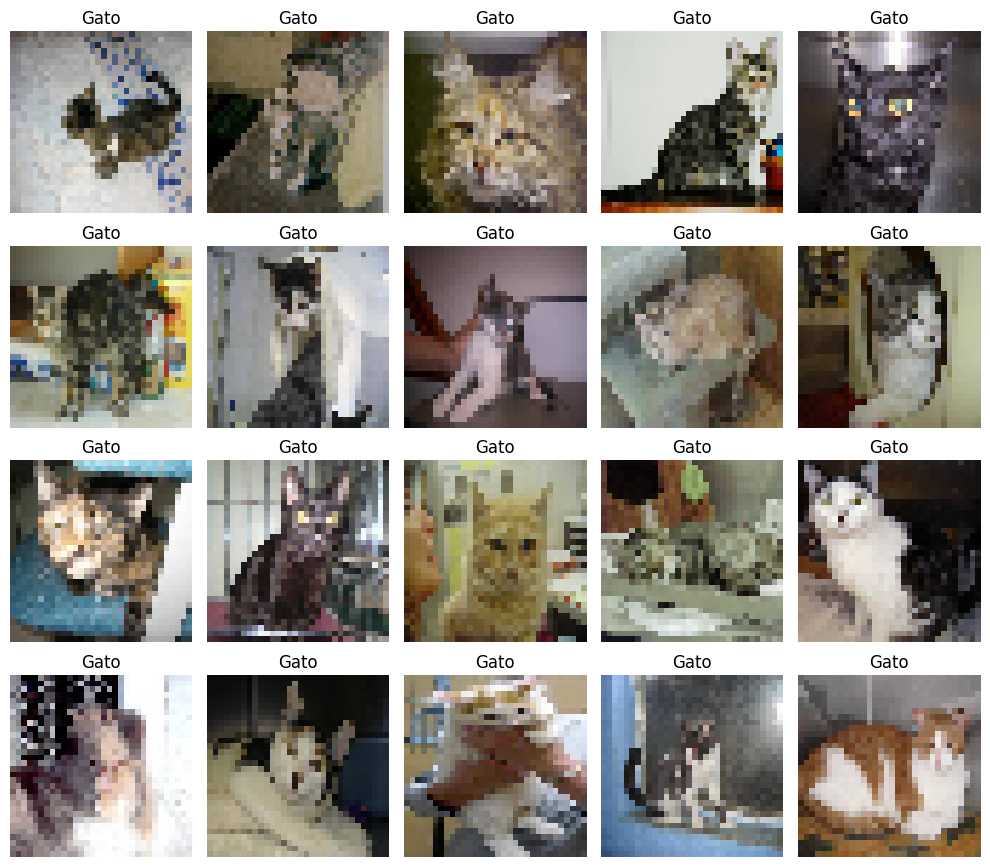

In [24]:
idxs = incertidumbre[:20]
plot_images(X_test[idxs], y_test[idxs])


In [25]:
prob = y_pred.flatten()          # probabilidad de ser perro
pred = y_pred_classes.flatten()  # clase predicha (0 gato, 1 perro)
true = y_test                    # clase real


In [26]:
errores_perro_gato = np.where((true == 1) & (pred == 0))[0]

errores_perro_gato_sorted = errores_perro_gato[np.argsort(prob[errores_perro_gato])[::-1]]

n = int(len(errores_perro_gato_sorted) * 0.10)
difíciles_perro_gato = errores_perro_gato_sorted[:n]


In [27]:
errores_gato_perro = np.where((true == 0) & (pred == 1))[0]

errores_gato_perro_sorted = errores_gato_perro[np.argsort(prob[errores_gato_perro])]

n2 = int(len(errores_gato_perro_sorted) * 0.10)
difíciles_gato_perro = errores_gato_perro_sorted[:n2]


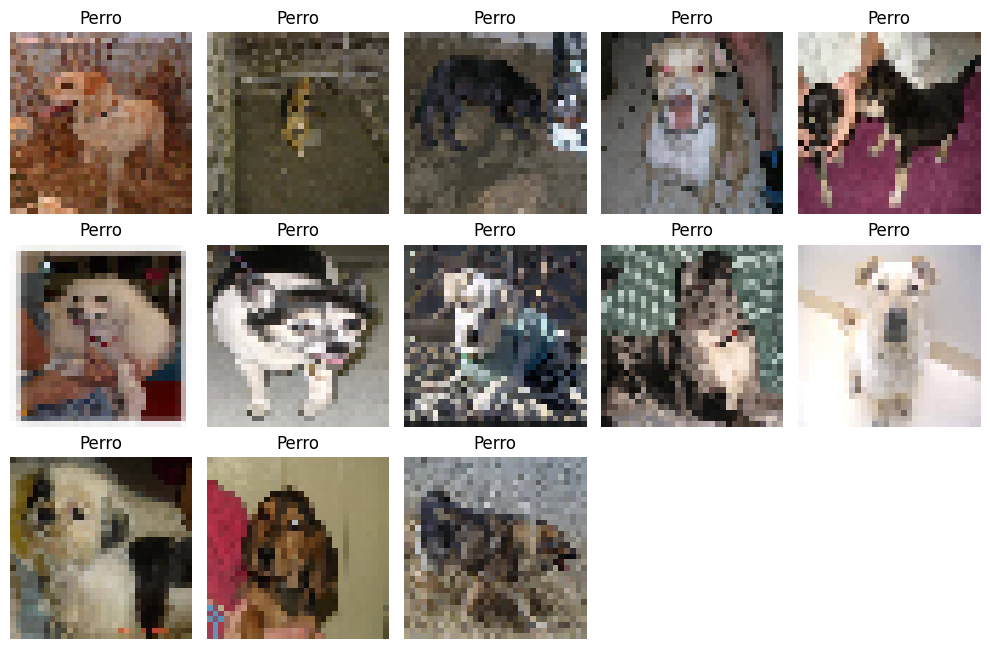

In [28]:
plot_images(X_test[difíciles_perro_gato], true[difíciles_perro_gato])


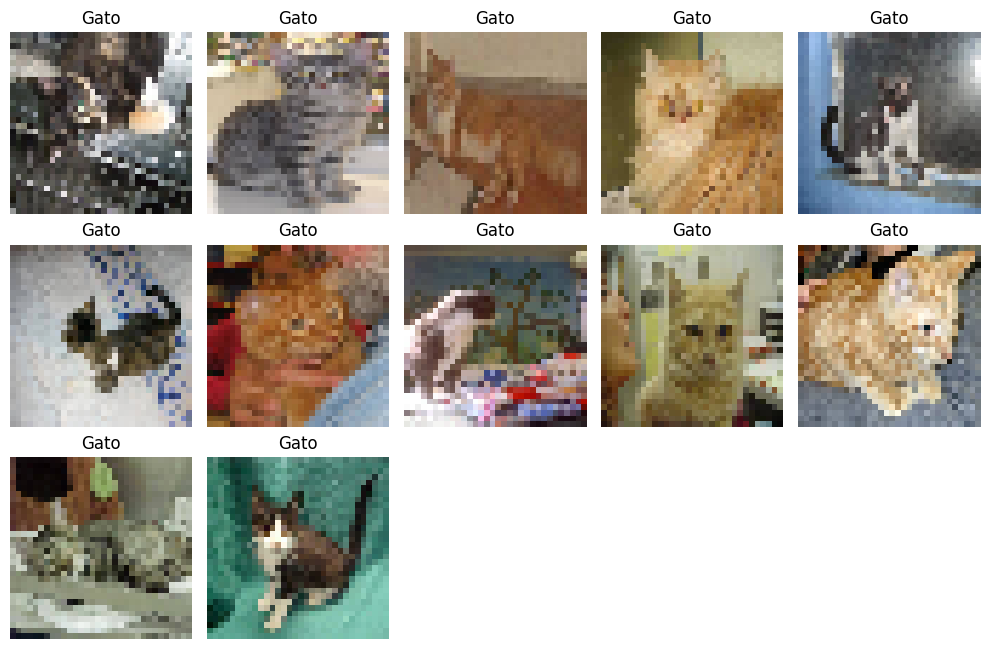

In [29]:
plot_images(X_test[difíciles_gato_perro], true[difíciles_gato_perro])
